## Task overview
I am given a single large image containing **~10,000 uppercase English letters (A–Z)**.  
Each letter is rendered with a **random font size (100–200)**, **random color**, can be **rotated**, and the image is additionally corrupted with **10–40 semi-transparent colored circles** per cell (noise).  

**Goal:** count how many times each letter appears on the image and submit the result as `letters.csv` in the format:
`A,11`, `B,10`, ...

## Approach (high level)
1. **Image preprocessing & segmentation**
   - Exploit the fact that the image is a grid (image size is divisible by the number of rows/columns).
   - Crop each grid cell to obtain candidate letter regions.
   - Reduce the impact of circle noise using simple filtering / morphology where needed.

2. **Training data**
   - Since the font is known (DejaVuSans-Bold), I generate a **synthetic labeled dataset** by rendering letters with random size/color/rotation and adding circle-like noise.
   - Apply augmentations to improve robustness (e.g., blur/noise, color jitter, partial occlusions).

3. **Model**
   - Train a lightweight **CNN classifier** on the synthetic dataset.
   - Validate using a held-out synthetic split and perform quick error analysis 

4. **Inference & submission**
   - Run inference on all cropped cells.
   - Aggregate predicted labels into counts and export `letters.csv`.

## Note on AI assistance 
I used ChatGPT as a **coding assistant for refactoring and formatting** (renaming variables, organizing functions, improving readability, and minor cleanup).  
All algorithmic decisions, experiments, and final solution logic were made and verified by me; ChatGPT was not used to “solve the task” end-to-end.


- Random seeds are fixed where applicable.

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import random
import numpy as np 
import pandas as pd 

font_path = '/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf'

font = ImageFont.truetype(font_path, size=random.randint(100, 200))

In [9]:
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

path = 'your path to file'

img = Image.open(path).convert('L')
print(img.size)
scale = 5
img_small = img.resize((img.width//scale, img.height//scale), Image.BILINEAR)

(30000, 30000)


In [11]:
import cv2, numpy as np
def binarize_ink(img_small):
    """
    Convert image to binary ink mask using OTSU thresholding.
    
    Args:
        img_small: Input grayscale image
        
    Returns:
        Boolean mask where True = ink pixels, False = background
    """
    gray = np.array(img_small, dtype=np.uint8)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    ink = bw > 0
    return ink


## Step 1 — Detecting the grid of letter tiles (100 × 100)

The original image is a regular grid: each letter is placed inside its own *tile* (cell), and the overall image size is divisible by the number of tiles both horizontally and vertically.


**Conclusion**
- The image contains **100 × 100 = 10,000** tiles.
- All tiles have identical size:
  - `tile_w = W / 100`
  - `tile_h = H / 100`
- This allows deterministic cropping: each tile can be extracted by simple indexing (row, col) without any object detection step.

In [ ]:
def projections(ink: np.ndarray):
    """
    Calculate horizontal and vertical projections of ink mask.
    
    Args:
        ink: Binary ink mask (boolean array)
        
    Returns:
        Tuple of (projection_x, projection_y) as float arrays
    """
    proj_x = ink.sum(axis=0).astype(np.float64) 
    proj_y = ink.sum(axis=1).astype(np.float64)
    return proj_x, proj_y

def smooth_1d(x: np.ndarray, k: int = 15) :
    """
    Smooth 1D signal using moving average.
    
    Args:
        x: Input signal
        k: Kernel size (will be odd)
        
    Returns:
        Smoothed signal
    """
    k = max(3, int(k) | 1)  
    kernel = np.ones(k, dtype=np.float64) / k
    return np.convolve(x, kernel, mode="same")

def gaps_from_proj(proj: np.ndarray, smooth_k: int = 15) :
    """
    Convert projection to gap signal (areas between ink regions).
    
    Args:
        proj: Projection signal
        smooth_k: Smoothing kernel size
        
    Returns:
        Smoothed gap signal
    """
    gap = proj.max() - proj
    gap = smooth_1d(gap, smooth_k)
    return gap
def estimate_period_autocorr(signal: np.ndarray, min_p: int, max_p: int) :
    """
    Estimate period using autocorrelation.
    
    Args:
        signal: Input signal
        min_p: Minimum period
        max_p: Maximum period
        
    Returns:
        Estimated period
        
    Raises:
        ValueError: If min_p >= max_p
    """
    s = signal.astype(np.float64)
    s = s - s.mean()
    ac = np.correlate(s, s, mode="full")[len(s)-1:]  
    ac[0] = 0.0

    max_p = min(max_p, len(ac)-1)
    if min_p >= max_p:
        raise ValueError("Bad min_p/max_p for autocorr.")

    window = ac[min_p:max_p+1]
    p = min_p + int(np.argmax(window))
    return p
def estimate_offset(gap: np.ndarray, period: int) :
    """
    Find best offset for grid alignment.
    
    Args:
        gap: Gap signal
        period: Estimated period
        
    Returns:
        Best offset value
    """
    best_off, best_score = 0, -1.0
    n = len(gap)
    for off in range(period):
        idx = np.arange(off, n, period)
        score = gap[idx].sum()
        if score > best_score:
            best_score, best_off = score, off
    return best_off

def grid_lines(n: int, period: int, offset: int):
    """
    Generate grid lines based on period and offset.
    
    Args:
        n: Maximum index
        period: Grid period
        offset: Starting offset
        
    Returns:
        List of line positions
    """
    lines = list(range(offset, n+1, period))
    lines = [x for x in lines if 0 <= x <= n]
    return lines


In [13]:
def estimate_grid(pil_img: Image.Image):
    """
    Estimate grid structure from image.
    
    Analyzes ink distribution to detect line spacing and grid layout
    using projections and autocorrelation.
    
    Args:
        pil_img: Input PIL Image
        
    Returns:
        Dictionary containing grid information:
        - rows: Number of rows
        - cols: Number of columns  
        - cell_w: Cell width in pixels
        - cell_h: Cell height in pixels
        - x_lines: Vertical line positions
        - y_lines: Horizontal line positions
        
    Prints:
        Image dimensions (height, width) to console
    """
    ink = binarize_ink(pil_img)
    H, W = ink.shape
    print(H, W)
    proj_x, proj_y = projections(ink)

    gap_x = gaps_from_proj(proj_x, smooth_k=max(9, W//200))
    gap_y = gaps_from_proj(proj_y, smooth_k=max(9, H//200))
    px = estimate_period_autocorr(gap_x, min_p=5, max_p=min(800, W//2))
    ox = estimate_offset(gap_x, px)
    x_lines = grid_lines(W, px, ox)
    py = estimate_period_autocorr(gap_y, min_p=5, max_p=min(800, H//2))
    oy = estimate_offset(gap_y, py)
    y_lines = grid_lines(H, py, oy)


    cols = len(x_lines) - 1
    rows = len(y_lines) - 1

    return {
        "rows": rows, "cols": cols,
        "cell_w": px, "cell_h": py,
        "x_lines": x_lines, "y_lines": y_lines
    }


In [14]:
ans = estimate_grid(img_small)

6000 6000


In [15]:
from PIL import Image
from typing import Iterator, Tuple, Optional, Union

def iter_tiles(
    img: Image.Image,
    tile_w: int,
    tile_h: Optional[int] = None,
    x0: int = 0,
    y0: int = 0,
    rows: Optional[int] = None,
    cols: Optional[int] = None,
    strict: bool = True,
    with_index: bool = True,
) :
    """
    Iterate over image tiles of specified size.
    
    Cuts image into tiles of size tile_w x tile_h starting from (x0, y0).
    
    Args:
        img: Input PIL Image
        tile_w: Tile width in pixels
        tile_h: Tile height in pixels (if None, equals tile_w)
        x0: Starting X offset
        y0: Starting Y offset
        rows: Number of rows (auto-calculated if None)
        cols: Number of columns (auto-calculated if None)
        strict: If True, ensures grid fits exactly (no leftovers)
        with_index: If True, yields (tile, r, c), else yields only tile
        
    Yields:
        Image tiles, optionally with row/column indices
        
    Raises:
        ValueError: If x0/y0 out of bounds or strict=True and grid doesn't fit
        
    Example:
        >>> for tile, r, c in iter_tiles(img, 75, 75):
        ...     process_tile(tile, r, c)
    """
    if tile_h is None:
        tile_h = tile_w

    W, H = img.size
    usable_w = W - x0
    usable_h = H - y0

    if usable_w <= 0 or usable_h <= 0:
        raise ValueError("x0/y0 out of size")

    if cols is None:
        cols = usable_w // tile_w
    if rows is None:
        rows = usable_h // tile_h

    grid_w = cols * tile_w
    grid_h = rows * tile_h

    if strict:
        if usable_w % tile_w != 0 or usable_h % tile_h != 0:
            raise ValueError(
                f"Не делится нацело: usable_w={usable_w}, tile_w={tile_w}, "
                f"usable_h={usable_h}, tile_h={tile_h}. "
                f"Поставь strict=False или задай rows/cols/x0/y0."
            )
        if x0 + grid_w != W or y0 + grid_h != H:
            raise ValueError(
                f"Сетка не покрывает всю картинку ровно. "
                f"Покрывает: ({x0}..{x0+grid_w})x({y0}..{y0+grid_h}), "
                f"картинка: 0..{W} x 0..{H}. "
                f"Если есть рамка — передай x0/y0 или strict=False."
            )

    for r in range(rows):
        top = y0 + r * tile_h
        for c in range(cols):
            left = x0 + c * tile_w
            tile = img.crop((left, top, left + tile_w, top + tile_h))
            if with_index:
                yield tile, r, c
            else:
                yield tile


def cut_tiles_list(
    img: Image.Image,
    tile_w: int,
    tile_h: Optional[int] = None,
    **kwargs
):
    """
    Cut image into tiles and return as list.
    
    Convenience wrapper around iter_tiles that returns a list of tiles.
    
    Args:
        img: Input PIL Image
        tile_w: Tile width in pixels
        tile_h: Tile height in pixels (if None, equals tile_w)
        **kwargs: Additional arguments passed to iter_tiles:
                 x0, y0, rows, cols, strict, with_index=False
        
    Returns:
        List of image tiles (without indices)
        
    Note:
        with_index is forced to False as list format doesn't support indices
        
    Example:
        >>> tiles = cut_tiles_list(img, 75, 75, strict=True)
        >>> for tile in tiles:
        ...     process_tile(tile)
    """
    return list(iter_tiles(img, tile_w, tile_h, **kwargs))


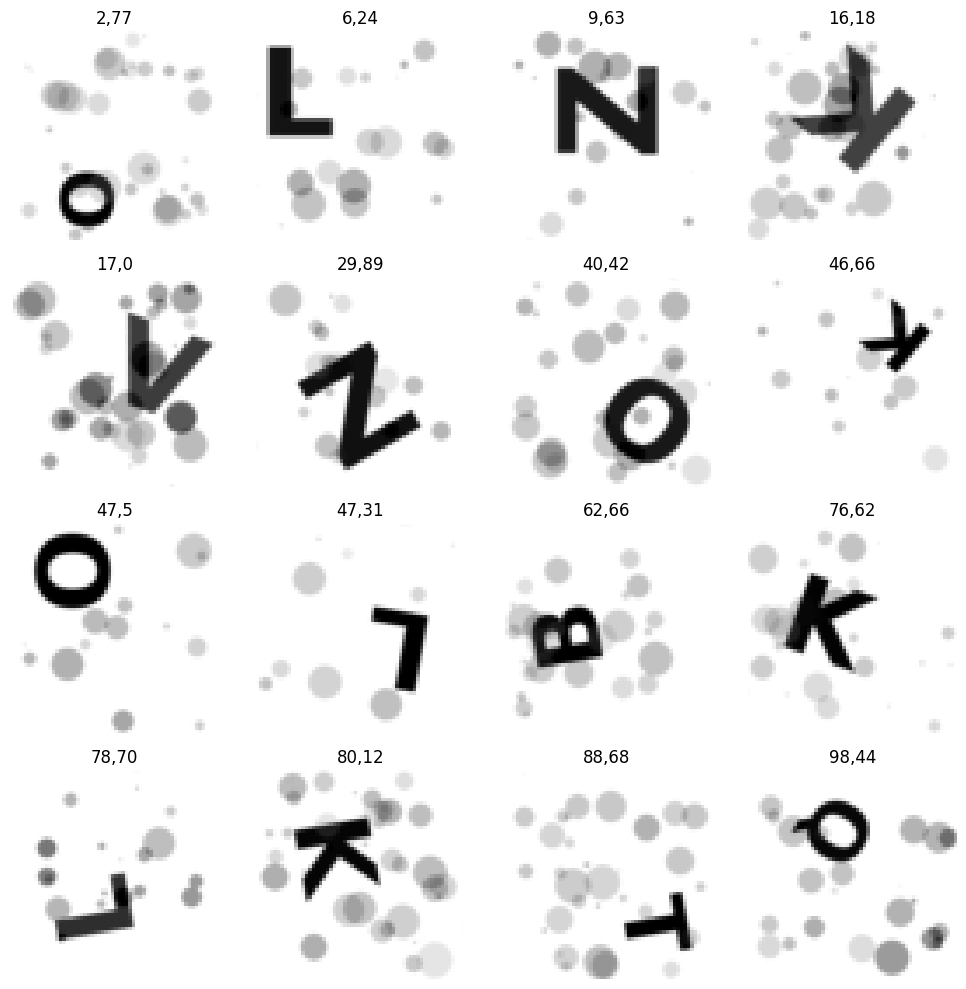

In [16]:
import random
import matplotlib.pyplot as plt

tile_w, tile_h = 60, 60
x0, y0 = 0, 0
n = 16

W, H = img_small.size
rows = (H - y0) // tile_h
cols = (W - x0) // tile_w
total = rows * cols

pick = set(random.sample(range(total), k=min(n, total)))
picked = []

for idx, (tile, r, c) in enumerate(iter_tiles(img_small, tile_w, tile_h, x0=x0, y0=y0, strict=False)):
    if idx in pick:
        picked.append((tile, r, c))
        if len(picked) == len(pick):
            break

plt.figure(figsize=(10, 10))
for k, (tile, r, c) in enumerate(picked, 1):
    plt.subplot(4, 4, k)
    plt.imshow(tile, cmap="gray" if tile.mode in ("L", "1") else None)
    plt.title(f"{r},{c}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Step 2 — Augmentations 

To make the classifier robust to the distortions present in the original image (random color, rotation, background clutter, and semi-transparent circles), I use a *label-conditional* augmentation pipeline during training.

Instead of applying the same augmentations to every class, the pipeline adapts augmentation strength to the letter type:
- **Fragile letters** (e.g., `N, K, M, W, Z, ...`) contain thin strokes and sharp corners, so aggressive occlusions can destroy their structure. For these classes I apply **milder hiding and circle noise**.
- **Round letters** (e.g., `O, D, P, Q, C, G`) are less sensitive to partial occlusions and are more likely to survive stronger perturbations. For these classes I allow **stronger occlusion and/or stronger circle noise**.
- **All other letters** use a default augmentation regime.

### What the transform does (in order)
Given an input PIL image `im` and its label `y`, `ConditionalTrainTransform(im, y)` applies:

1. **Color / ink simulation** (`InkToGrayV2`, with high probability)  
   I convert letters to realistic grayscale "ink-like" tones to reduce reliance on exact RGB colors and make the model focus on shape.

2. **Geometric distortions** (`RandomAffine`, p≈0.95)  
   Large rotations, translations, and scaling simulate the generation process and create invariance to position/angle/size.

3. **Circle noise (label-conditional)** (`AddCircles`, with class-dependent probability)  
   Semi-transparent circles are added to imitate the main source of clutter in the target image.

4. **One-of degradation (stochastic choice)** (`none` / `HideAndSeekInk` / `GaussianBlur`)  
   With probability `oneof_p`, I randomly apply either:
   - **no additional degradation**, or
   - **ink hiding / occlusion** (class-dependent), or
   - **blur**  
   This prevents the model from overfitting to a single corruption type and improves generalization.

5. **Light photometric jitter** (`ColorJitter`, low probability)  
   Minor brightness variation further reduces dependence on absolute intensity.

6. **Tensor conversion + normalization**  
   The final output is a normalized tensor (ImageNet-style mean/std), ready for CNN training.

### Why this helps
The target image is heavily corrupted, so a model trained on clean synthetic crops tends to learn shortcuts (e.g., a single vertical stroke) and collapses predictions to visually similar classes (e.g., `I` vs `L/J`).  
Label-conditional augmentations help avoid *over-destroying* fragile classes while still enforcing robustness where it is safe. As a result, the classifier becomes less biased toward shortcut features and behaves more realistically under clutter and partial occlusion.

In [17]:
from string import ascii_uppercase
base_letters = list()
for letter in list(ascii_uppercase):
    image_for_dataset = Image.new('L', size = (256,256), color = 255)
    draw = ImageDraw.Draw(image_for_dataset)
    font = ImageFont.truetype(font_path, size= 180)
    text_color = 'rgb(30, 30, 30)'
    draw.text((256/2, 256/2), text = letter, fill=text_color, font=font, anchor="mm")
    base_letters.append(image_for_dataset)


In [19]:
import random
from PIL import Image, ImageDraw, ImageFilter

class AddCircles:
    """
    Augmentation that adds random semi-transparent circles to an image.
    
    Can add circles either one by one (with individual blur) or all at once
    (with global blur). Useful for simulating noise or artistic effects.
    
    Args:
        n_range: Tuple of (min, max) number of circles
        r_range: Tuple of (min, max) circle radius in pixels
        gray_range: Tuple of (min, max) grayscale value (0-255)
        alpha_range: Tuple of (min, max) alpha transparency (0-255)
        blur_range: Tuple of (min, max) Gaussian blur radius
        per_circle_compose: If True, apply blur per circle; if False, global blur
        p: Probability of applying augmentation (0.0 to 1.0)
        
    Example:
        >>> aug = AddCircles(p=0.5)
        >>> augmented_img = aug(original_img)
    """
    def __init__(self,
                 n_range=(10, 25),
                 r_range=(10, 20),
                 gray_range=(140, 230), 
                 alpha_range=(40, 140),   
                 blur_range=(0, 2),      
                 per_circle_compose=True, 
                 p=0.8):
        self.n_range = n_range
        self.r_range = r_range
        self.gray_range = gray_range
        self.alpha_range = alpha_range
        self.blur_range = blur_range
        self.per_circle_compose = per_circle_compose
        self.p = p

    def __call__(self, im):
        """
        Apply circle augmentation to image.
        
        Args:
            im: Input PIL Image
            
        Returns:
            PIL Image with circles added (same mode as input)
        """
        if random.random() > self.p:
            return im

        base = im.convert("RGBA")
        W, H = base.size
        n = random.randint(*self.n_range)

        if self.per_circle_compose:
            for _ in range(n):
                r = random.randint(*self.r_range)
                x = random.randint(0, W - 1)
                y = random.randint(0, H - 1)
                g = random.randint(*self.gray_range)
                a = random.randint(*self.alpha_range)
                blur = random.randint(*self.blur_range)

                layer = Image.new("RGBA", (W, H), (0, 0, 0, 0))
                draw = ImageDraw.Draw(layer)
                draw.ellipse((x - r, y - r, x + r, y + r), fill=(g, g, g, a))

                if blur > 0:
                    layer = layer.filter(ImageFilter.GaussianBlur(radius=blur))

                base = Image.alpha_composite(base, layer)
            out = base

        else:
            overlay = Image.new("RGBA", (W, H), (0, 0, 0, 0))
            draw = ImageDraw.Draw(overlay)
            for _ in range(n):
                r = random.randint(*self.r_range)
                x = random.randint(0, W - 1)
                y = random.randint(0, H - 1)
                g = random.randint(*self.gray_range)
                a = random.randint(*self.alpha_range)
                draw.ellipse((x - r, y - r, x + r, y + r), fill=(g, g, g, a))

            blur = random.randint(*self.blur_range)
            if blur > 0:
                overlay = overlay.filter(ImageFilter.GaussianBlur(radius=blur))

            out = Image.alpha_composite(base, overlay)

        return out.convert(im.mode)

In [20]:
import random
import numpy as np
from PIL import Image, ImageDraw, ImageFilter

class HideAndSeekInk:
    """
    Random Erasing targeted at ink regions (characters) in images.
    
    This augmentation selectively erases parts of text by drawing rectangles
    over ink areas, helping models become robust to occlusions and preventing
    overfitting to specific character shapes (e.g., confusing 'I' with 'T').
    
    The erasure positions are sampled from actual ink pixels, ensuring that
    modifications target text regions rather than background.
    
    Args:
        n_range: Tuple of (min, max) number of erasure rectangles per image
        size_frac_range: Tuple of (min, max) fraction of character size for erasure
        aspect_range: Tuple of (min, max) aspect ratio of erasure rectangles
        thr_percentile: Percentile threshold for ink detection
        thr_max: Maximum threshold value (clamps thr_percentile)
        alpha_range: Tuple of (min, max) alpha transparency for erasures
        blur_range: Tuple of (min, max) Gaussian blur radius for erasures
        p: Probability of applying augmentation (0.0 to 1.0)
        fill: Color of erasure rectangle (int for grayscale, tuple for RGB)
        
    Example:
        >>> aug = HideAndSeekInk(p=0.5, fill=(255, 255, 255))
        >>> augmented_img = aug(document_image)
    """
    def __init__(self,
                 n_range=(1, 3), 
                 size_frac_range=(0.12, 0.35),  
                 aspect_range=(0.3, 3.3),  
                 thr_percentile=8.0,
                 thr_max=130, 
                 alpha_range=(0, 255), 
                 blur_range=(0, 2),   
                 p=0.7,
                 fill=(255, 255, 255)):      
        self.n_range = n_range
        self.size_frac_range = size_frac_range
        self.aspect_range = aspect_range
        self.thr_percentile = thr_percentile
        self.thr_max = thr_max
        self.alpha_range = alpha_range
        self.blur_range = blur_range
        self.p = p
        self.fill = fill

    def __call__(self, im: Image.Image) -> Image.Image:
        """
        Apply ink-targeted erasure augmentation.
        
        Args:
            im: Input PIL Image
            
        Returns:
            PIL Image with random rectangles erased from ink regions
        """
        base = im.convert("RGBA")
        W, H = base.size
        gray = np.array(im.convert("L"), dtype=np.uint8)
        thr = np.percentile(gray, self.thr_percentile)
        thr = min(float(thr), float(self.thr_max))
        ink = gray <= thr

        if ink.sum() < 30: 
            return im

        ys, xs = np.where(ink)
        y0, y1 = int(ys.min()), int(ys.max())
        x0, x1 = int(xs.min()), int(xs.max())
        bw = max(1, x1 - x0 + 1)
        bh = max(1, y1 - y0 + 1)
        m = min(bw, bh)

        n = random.randint(*self.n_range)

        coords = list(zip(xs.tolist(), ys.tolist()))

        for _ in range(n):
            cx, cy = random.choice(coords)

            frac = random.uniform(*self.size_frac_range)
            hole_base = max(2, int(frac * m))
            aspect = random.uniform(*self.aspect_range)

            w = max(2, int(hole_base * np.sqrt(aspect)))
            h = max(2, int(hole_base / np.sqrt(aspect)))

            w = min(w, int(1.2 * bw))
            h = min(h, int(1.2 * bh))

            xA = max(0, cx - w // 2)
            yA = max(0, cy - h // 2)
            xB = min(W - 1, cx + w // 2)
            yB = min(H - 1, cy + h // 2)

            a = random.randint(*self.alpha_range)
            blur = random.randint(*self.blur_range)

            layer = Image.new("RGBA", (W, H), (0, 0, 0, 0))
            draw = ImageDraw.Draw(layer)

            r, g, b = self.fill if isinstance(self.fill, tuple) else (self.fill,)*3
            draw.rectangle((xA, yA, xB, yB), fill=(r, g, b, a))

            if blur > 0:
                layer = layer.filter(ImageFilter.GaussianBlur(radius=blur))

            base = Image.alpha_composite(base, layer)

        return base.convert(im.mode)

In [240]:
import random
import torchvision.transforms as T

class ConditionalTrainTransform:
    """
    Conditional transformation pipeline for document image training.
    
    Applies different augmentation strategies based on character class labels.
    Uses label-adaptive augmentations: fragile letters (e.g., 'N', 'K') get
    different treatment than round letters (e.g., 'O', 'Q').
    
    The pipeline includes:
    - Random affine transformations
    - Label-conditional ink hiding (HideAndSeekInk)
    - Label-conditional circle noise (AddCircles)
    - One-of degradation selection (blur, hide, or nothing)
    - Color jitter
    - Final tensor conversion and normalization
    
    Args:
        affine_p: Probability of applying affine transform
        affine_kwargs: Dict of args for T.RandomAffine
        blur_p: Weight for blur in one-of selection
        blur_kwargs: Dict of args for T.GaussianBlur
        jitter_p: Probability of color jitter
        jitter_kwargs: Dict of args for T.ColorJitter
        hide_soft: Soft HideAndSeekInk instance
        hide_strong: Aggressive HideAndSeekInk instance
        circles_soft: Soft AddCircles instance  
        circles_strong: Aggressive AddCircles instance
        p_hide_default: Hide probability for default classes
        p_hide_fragile: Hide probability for fragile letters
        p_hide_roundy: Hide probability for round letters
        p_circles_default: Circle probability for default classes
        p_circles_fragile: Circle probability for fragile letters
        p_circles_roundy: Circle probability for round letters
        fragile_labels: Set of character labels treated as fragile
        roundy_labels: Set of character labels treated as round
        label_adapter: Optional function to convert raw labels
        oneof_p: Probability of applying one-of degradation
        none_weight: Weight for "no degradation" in one-of
        mean: Normalization mean (RGB)
        std: Normalization std (RGB)
        tmp: If True, return PIL image instead of tensor
    """

    def __init__(
        self,
        affine_p=0.95,
        affine_kwargs=None,

        blur_p=0.2,     
        blur_kwargs=None,

        jitter_p=0.2,
        jitter_kwargs=None,


        hide_soft=None,  
        hide_strong=None,  
        circles_soft=None, 
        circles_strong=None,  

        p_hide_default=0.7,
        p_hide_fragile=0.1,
        p_hide_roundy=0.2,

        p_circles_default=0.8,
        p_circles_fragile=0.7,
        p_circles_roundy=0.6,


        fragile_labels=set(list("NKMZWXVYERBF")),
        roundy_labels=set(list("ODPQCG")),

        label_adapter=None,


        oneof_p=0.8,  
        none_weight=0.2,   


        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        tmp=False
    ):
        self.to_rgb = T.Lambda(lambda im: im.convert("RGB"))

        affine_kwargs = affine_kwargs or dict(
            degrees=140,
            translate=(0.1, 0.3),
            scale=(0.3, 0.5),
            fill=(255, 255, 255),
        )
        self.color = InkToGrayV2(p=1, gray_range=(30, 90), alpha_range=(0.9, 1.0), thr_percentile=20, thr_cap=200)
        self.color_p = 0.9
        
        self.affine = T.RandomAffine(**affine_kwargs)
        self.affine_p = affine_p

        blur_kwargs = blur_kwargs or dict(kernel_size=3, sigma=(0.1, 1.2))
        self.blur = T.GaussianBlur(**blur_kwargs)
        self.blur_p = float(blur_p)

        jitter_kwargs = jitter_kwargs or dict(brightness=(1.4, 1.4))
        self.jitter = T.ColorJitter(**jitter_kwargs)
        self.jitter_p = jitter_p

        self.hide_soft = hide_soft
        self.hide_strong = hide_strong
        self.circles_soft = circles_soft
        self.circles_strong = circles_strong

        self.p_hide_default = float(p_hide_default)
        self.p_hide_fragile = float(p_hide_fragile)
        self.p_hide_roundy = float(p_hide_roundy)

        self.p_circles_default = float(p_circles_default)
        self.p_circles_fragile = float(p_circles_fragile)
        self.p_circles_roundy = float(p_circles_roundy)

        self.fragile = fragile_labels
        self.roundy = roundy_labels

        self.label_adapter = label_adapter  

        self.oneof_p = float(oneof_p)
        self.none_weight = float(none_weight)

        self.to_tensor = T.ToTensor()
        self.norm = T.Normalize(mean=mean, std=std)
        self.tmp = tmp

    def _adapt_label(self, y):
        """Convert raw label using adapter if provided."""
        return self.label_adapter(y) if self.label_adapter is not None else y

    def _pick_hide_for_label(self, y):
        """Select hide transform and probability based on label group."""
        if y in self.fragile:
            w = self.p_hide_fragile
            t = self.hide_soft 
        elif y in self.roundy:
            w = self.p_hide_roundy
            t = (self.hide_strong or self.hide_soft)
        else:
            w = self.p_hide_default
            t = self.hide_soft
        if t is None or w <= 0.0:
            return None, 0.0
        return t, w

    def _apply_oneof_degrade(self, im, y):
        """
        Apply one-of degradation selection: [none, hide, blur] weighted by label.
        """
        if random.random() > self.oneof_p:
            return im

        ops = []
        weights = []

        ops.append(None)
        weights.append(self.none_weight)

        hide_t, hide_w = self._pick_hide_for_label(y)
        if hide_t is not None and hide_w > 0:
            ops.append(hide_t)
            weights.append(hide_w)

        if self.blur is not None and self.blur_p > 0:
            ops.append(self.blur)
            weights.append(self.blur_p)

        if len(ops) == 1:
            return im


        s = sum(weights)
        if s <= 0:
            return im
        weights = [w / s for w in weights]

        choice = random.choices(ops, weights=weights, k=1)[0]
        if choice is None:
            return im
        return choice(im)

    def __call__(self, im, y):
        """
        Apply conditional augmentation pipeline.
        
        Args:
            im: Input PIL Image
            y: Label (character class)
            
        Returns:
            Augmented PIL image (if tmp=True) or normalized tensor
        """
        y = self._adapt_label(y)

        im = self.to_rgb(im)

        if random.random() < self.color_p:
            im = self.color(im)

        if random.random() < self.affine_p:
            im = self.affine(im)


        if y in self.fragile:
            if self.circles_soft is not None and random.random() < self.p_circles_fragile:
                im = self.circles_soft(im)
        elif y in self.roundy:
            if (self.circles_strong or self.circles_soft) is not None and random.random() < self.p_circles_roundy:
                im = (self.circles_strong or self.circles_soft)(im)
        else:
            if self.circles_soft is not None and random.random() < self.p_circles_default:
                im = self.circles_soft(im)


        im = self._apply_oneof_degrade(im, y)

        if random.random() < self.jitter_p:
            im = self.jitter(im)

        if self.tmp:
            return im

        x = self.to_tensor(im)
        x = self.norm(x)
        return x

In [241]:
hide_soft = HideAndSeekInk(p=1.0)  
hide_strong = HideAndSeekInk(p=1.0)    

circles_soft = AddCircles(
    n_range=(10, 30),
    r_range=(2, 20),
    gray_range=(1, 10),
    alpha_range=(60, 90),
    p=1.0
)
circles_strong = AddCircles(
    n_range=(20, 45),
    r_range=(2, 26),
    gray_range=(1, 12),
    alpha_range=(70, 120),
    p=1.0
)


transform_train = ConditionalTrainTransform(
    hide_soft=hide_soft,
    hide_strong=hide_strong,
    circles_soft=circles_soft,
    circles_strong=circles_strong,
    oneof_p=0.75,
    none_weight=0.35
)

Example

/tmp/ipykernel_55/1234992676.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_img = Image.fromarray(mask, mode="L")
/tmp/ipykernel_55/1234992676.py:55: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(out, mode="RGB").convert(mode0)


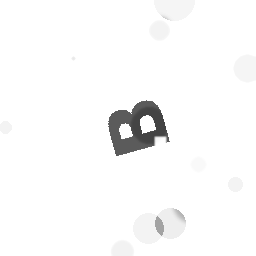

In [257]:
i = 1
transform_tmp = ConditionalTrainTransform(
    hide_soft=hide_soft,
    hide_strong=hide_strong,
    circles_soft=circles_soft,
    circles_strong=circles_strong,
    oneof_p=0.8,
    none_weight=0.35,
    tmp = True
)
letter_A = base_letters[i]
letter_A = transform_tmp(letter_A, i)
letter_A

In [57]:
from torch.utils.data import Dataset
class RandomLettersDataset(Dataset):
    """
    Dataset that cycles through letter images with controlled sampling.
    
    Creates batches by repeatedly sampling from a fixed set of letter images.
    Each sample is generated by taking an image corresponding to a letter class
    (0-25 for A-Z) and optionally applying conditional augmentations.
    
    The dataset length is fixed to batch_size, making it ideal for infinite
    sampling in training loops where you want to control batch composition.
    
    Args:
        images: List or array of images, indexed by class (0-25)
        transform: Optional callable that takes (image, label) and returns transformed image
        batch_size: Length of dataset (samples per epoch)

    """
    def __init__(self, images,  transform=None, batch_size = 128):
        self.images = images
        self.transform = transform
        self.batch_size = batch_size

    def __len__(self):
        return self.batch_size

    def __getitem__(self, i):
        """
        Get sample by cycling through classes.
        
        Args:
            i: Index from 0 to batch_size-1
            
        Returns:
            Tuple of (image, label) where label = i % 26
        """
        y = i % 26
        x = self.images[y].copy()
        if self.transform :
            x = self.transform(x, y)
        return x, y
    

## Step 3 — Validation set close to the target distribution (stress validation)

To make validation meaningful, I generate a separate validation set using augmentations that are **intentionally close to the real data distribution**.

### How the validation set is constructed
1. **Base templates:** I start from 26 clean base letter images (`base_letters`), one per class A–Z.
2. **Deterministic generation:** for each class I generate `n_per_class` samples  with fixed seeds. This makes the validation set **fully reproducible**.
3. **Disk format for easy loading:** samples are saved to `val_set/<LETTER>/xxxxx.png` and I create:
   - `label2id.txt` (A→0, …, Z→25)
   - `meta.csv` with `(rel_path, label_char, label_id)`  
   so the dataset can be loaded without relying on directory scanning heuristics.

### Target-like validation augmentations 
The `val_aug` pipeline is designed to mimic the main distortions of the original image:

- **RGB conversion**: ensures consistent color mode.
- **Ink / grayscale simulation (`InkToGrayV2`)**: reduces dependence on exact colors and makes letters look like real “ink” strokes.
- **Strong geometry (`RandomAffine`)**: large rotations + translation + scale, to match random placement/rotation and size variation.
- **Circle clutter (`AddCircles`)**: adds 15–40 semi-transparent circles with randomized radius and intensity to replicate the main noise source.
- **Occasional blur (`GaussianBlur`)**: simulates local blur / low-quality rendering.

### Why I do this
The goal of this validation is to estimate how well the model will generalize to the actual target image.  
This “stress validation” reveals typical failure modes (e.g., confusions between visually similar letters) and helps tune augmentations and training settings based on behavior under realistic noise.

In [258]:
from pathlib import Path
import csv
import random
import torch

def make_and_save_val_set(
    base_images,      
    out_dir="/kaggle/working/val_set",
    n_per_class=200,  
    aug=None,        
    seed_base=12345,
    force_rgb=True,
    ext="png",
):
    """
    Generate and save validation dataset with controlled augmentation.
    
    Creates a structured validation set by augmenting base images for each
    letter class (A-Z). Saves images in class subdirectories and generates
    metadata files for easy loading.
    
    Args:
        base_images: List of 26 PIL Images (one per letter A-Z)
        out_dir: Output directory path
        n_per_class: Number of augmented samples per letter class
        aug: Optional augmentation callable (takes PIL, returns PIL)
        seed_base: Base seed for reproducibility
        force_rgb: Convert images to RGB mode
        ext: Output image extension (e.g., 'png', 'jpg')
        
    Returns:
        Tuple of (output_dir_path, meta_csv_path)
        
    Files created:
        - label2id.txt: Mapping from letter to class ID
        - meta.csv: CSV with columns [rel_path, label_char, label_id]
        - Class subdirectories (A-Z/) containing augmented images
    """
    
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    letters = [chr(ord("A") + i) for i in range(26)]
    assert len(base_images) == 26, "base_images должен быть длины 26 (A..Z)"


    with open(out_dir / "label2id.txt", "w", encoding="utf-8") as f:
        for i, ch in enumerate(letters):
            f.write(f"{ch}\t{i}\n")


    meta_path = out_dir / "meta.csv"
    with open(meta_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["rel_path", "label_char", "label_id"])

        for y, ch in enumerate(letters):
            cls_dir = out_dir / ch
            cls_dir.mkdir(parents=True, exist_ok=True)

            base = base_images[y]

            for k in range(n_per_class):
                seed = seed_base + y * 1_000_000 + k
                torch.manual_seed(seed)
                random.seed(seed)

                img = base.copy()
                if force_rgb:
                    img = img.convert("RGB")

                if aug is not None:
                    img = aug(img)

                fname = f"{k:05d}.{ext}"
                rel_path = f"{ch}/{fname}"
                img.save(out_dir / rel_path)

                w.writerow([rel_path, ch, y])

    return str(out_dir), str(meta_path)


import torchvision.transforms as T

val_aug = T.Compose([
    T.Lambda(lambda im: im.convert("RGB")),
    InkToGrayV2(p=1, gray_range=(0, 90), alpha_range=(0.9, 1.0), thr_percentile=20, thr_cap=200),
    T.RandomApply([T.RandomAffine(degrees=140, translate=(0.1, 0.3), scale=(0.3, 0.5), fill=(255,255,255))], p=0.9),
    AddCircles(n_range=(15, 40),
                 r_range=(2, 20),
                 gray_range=(1, 10),
                 alpha_range=(60, 90), p=0.9),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2))], p=0.2)
])

out_dir, meta = make_and_save_val_set(base_letters, n_per_class=200, aug=val_aug)
out_dir = '/kaggle/working/val_set'
meta = '/kaggle/working/val_set/meta.csv'
print(out_dir, meta)


/tmp/ipykernel_55/1234992676.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_img = Image.fromarray(mask, mode="L")
/tmp/ipykernel_55/1234992676.py:55: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(out, mode="RGB").convert(mode0)


/kaggle/working/val_set /kaggle/working/val_set/meta.csv


## Step 4 — Training setup 

After building a target-like validation set, I train a CNN classifier using PyTorch Lightning.  
The training setup is intentionally split into two parts:

### 1) Training data: generated on-the-fly
For training I use `RandomLettersDataset`, which **generates synthetic letter crops on-the-fly** from 26 base templates (A–Z) and applies the `ConditionalTrainTransform(im, y)` augmentation pipeline.

**Why on-the-fly generation helps**
- Avoids storing a huge training dataset on disk.
- Produces *fresh* augmented samples every epoch, reducing overfitting to a limited set of synthetic images.
- Makes it easy to tune augmentation strength without re-exporting the dataset.

In the Lightning `LettersDataModule`, `epoch_size` controls how many samples are generated per epoch (i.e., the effective dataset length).

### 2) Validation data: fixed and reproducible
For validation I use a **pre-generated dataset saved to disk** (`val_set/`) with `meta.csv` and fixed seeds.  


This design ensures validation is:
- **stable across runs** (no randomness during evaluation),
- **closer to the target distribution**,
- suitable for comparing training configurations fairly.

### 3) Model: EfficientNet-B0 classifier
I use **EfficientNet-B0** pretrained on ImageNet and replace the final classifier layer with a 26-way linear head.

**Why EfficientNet-B0**
- Strong baseline for small image classification tasks.
- Good accuracy/compute trade-off.
- Pretraining helps learn robust low-level features (edges, strokes) even when training data is synthetic.

Training objective:
- `CrossEntropyLoss` for 26-class classification.
Metrics logged:
- `train_loss`, `train_acc`, `val_loss`, `val_acc`

### 4) Optimizer
I train with **AdamW** (weight decay regularization), which typically works well for fine-tuning pretrained CNNs:
- learning rate: `3e-4`
- weight decay: `1e-4`

Overall, this setup matches the key goal of the assignment: train on diverse synthetic corruption while validating on a realistic, fixed, target-like split.

In [ ]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

val_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])


val_ds = ImageFolder(out_dir, transform=val_tf)

class LettersDataModule(pl.LightningDataModule):
    """
    PyTorch Lightning DataModule for letter classification with on-the-fly augmentation.
    
    Handles training and validation data loading for letter recognition tasks.
    Training data is generated on-the-fly using RandomLettersDataset, while
    validation uses a fixed pre-generated dataset.
    
    Args:
        base_images: List of 26 base PIL Images (one per letter A-Z)
        train_tf: Callable that takes (image, label) and returns augmented training image
        val_tf: Callable that takes PIL image and returns transformed validation image
        batch_size: Batch size for both train and validation loaders
        epoch_size: Number of training samples per epoch (defines dataset length)
        val_size: Number of validation samples
        num_workers: Number of DataLoader worker processes
        val_ds: Pre-built validation dataset (optional)
    """
    def __init__(self, base_images, train_tf, val_tf,
                 batch_size=128, epoch_size=26*2000, val_size=26*200,
                 num_workers=2, val_ds = None):
        super().__init__()
        self.base_images = base_images
        self.train_tf = train_tf
        self.val_tf = val_tf
        self.batch_size = batch_size
        self.epoch_size = epoch_size
        self.val_size = val_size
        self.num_workers = num_workers
        self.val_ds = val_ds

    def setup(self, stage=None):
        """
        Initialize training dataset.
        
        Args:
            stage: Lightning stage ('fit', 'validate', 'test', or None)
        """
        self.train_ds = RandomLettersDataset(images = self.base_images,  batch_size = self.epoch_size, transform =self.train_tf)

    def train_dataloader(self):
        """
        Create training DataLoader with on-the-fly augmentation.
        
        Returns:
            DataLoader for training
        """
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True,
                          num_workers=self.num_workers, pin_memory=True, drop_last=True)

    def val_dataloader(self):
        """
        Create validation DataLoader from fixed dataset.
        
        Returns:
            DataLoader for validation
        """
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False,
                          num_workers=self.num_workers, pin_memory=True)


In [62]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torchvision import models

class EfficientNetLetters(pl.LightningModule):
    def __init__(self, num_classes=26, lr=3e-4, weight_decay=1e-4):
        super().__init__()
        self.save_hyperparameters()

        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        self.net = models.efficientnet_b0(weights=weights)

        in_f = self.net.classifier[1].in_features
        self.net.classifier[1] = nn.Linear(in_f, num_classes)

        self.crit = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.crit(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log_dict({"train_loss": loss, "train_acc": acc}, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.crit(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log_dict({"val_loss": loss, "val_acc": acc}, prog_bar=True)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        return opt


In [259]:
model = EfficientNetLetters(num_classes=26, lr=3e-4)
dm = LettersDataModule(base_letters, transform_train, transform_train,
    batch_size=128,      
    epoch_size=26*1000,  
    val_size=26*200,
    num_workers=4,
    val_ds = val_ds)



In [264]:
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=10
)

trainer.fit(model, datamodule=dm)  
trainer.save_checkpoint("effnet_letters.ckpt")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type             ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ net  │ EfficientNet     │  4.0 M │ eval │     0 │
│ 1 │ crit │ CrossEntropyLoss │      0 │ eval │     0 │
└───┴──────┴──────────────────┴────────┴──────┴───────┘

Trainable params: 4.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.0 M                                                                                                
Total estimated model params size (MB): 16                                                                         
Modules in train mode: 0                                                                                           
Modules in eval mode: 338                                                                                          
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:534: Found 339 module(s) in eval mode 
at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can 
ignore this warning.

`Trainer.fit` stopped: `max_epochs=10` reached.


`weights_only` was not set, defaulting to `False`.


## Step 5 — Quick visual sanity check on random tiles

Before running inference on the full 100×100 grid, I do a quick qualitative check to ensure that:
- tile extraction works correctly,
- the preprocessing used at inference time matches training/validation,
- the model outputs sensible predictions on real tiles.

1. **Switch model to evaluation mode** and move it to GPU if available .
2. **Compute grid shape**
3. **Randomly sample up to 16 tile indices** from the full grid.
4. **Extract selected tiles** .
5. **Run a single forward pass** on the batch of selected tiles:
   - convert each tile with the inference transform `post(...)`
   - stack into a tensor batch and predict `argmax` class indices
6. **Plot a 2×8 visualization**.

### Why this matters
This step catches common pipeline issues early  
Even if quantitative validation looks fine, a quick visualization often reveals systematic mistakes

In [93]:
import torchvision.transforms as T

post = T.Compose([
    T.Lambda(lambda im: im.convert("RGB")),
    T.Resize((256,256)),
    T.ToTensor(),
    T.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])


In [265]:
img = Image.open(path).convert('L')

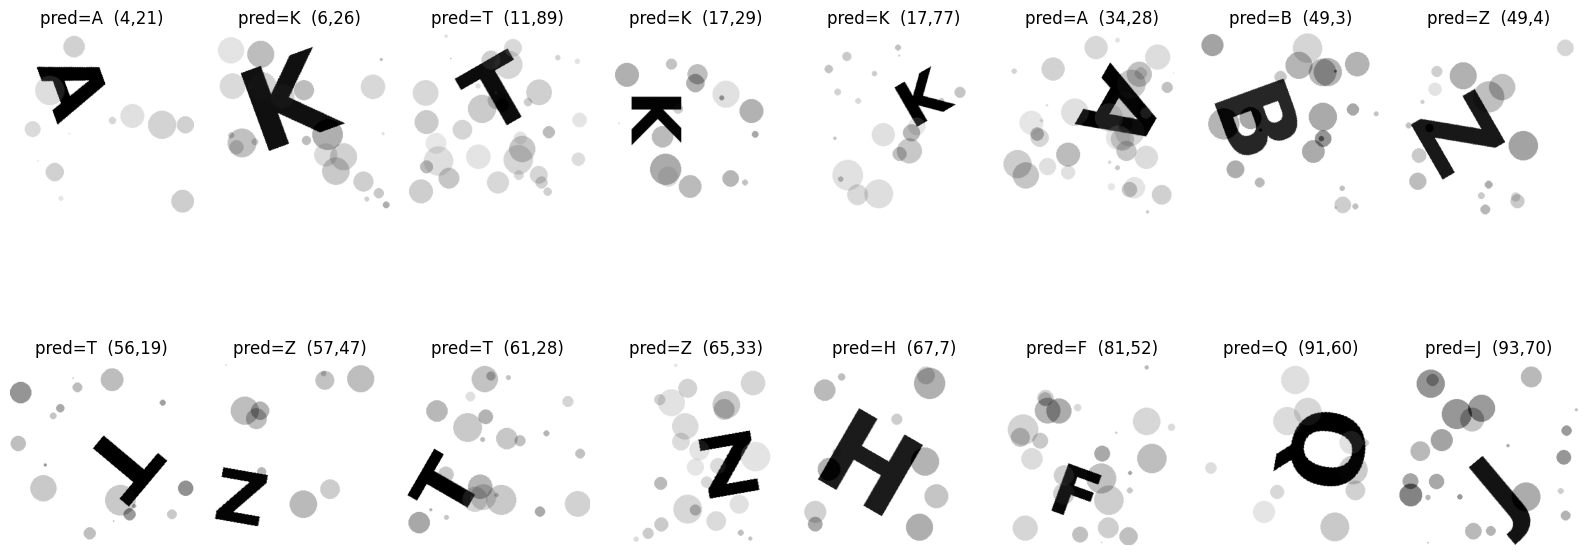

In [282]:
import random
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval().to(device)

tile_w, tile_h = 60*5, 60*5
x0, y0 = 0, 0

W, H = img.size
rows = (H - y0) // tile_h
cols = (W - x0) // tile_w
total = rows * cols

pick = set(random.sample(range(total), k=min(16, total)))

picked = []
for idx, (tile, r, c) in enumerate(iter_tiles(img, tile_w, tile_h, x0=x0, y0=y0, strict=False)):
    if idx in pick:
        picked.append((tile, r, c))
        if len(picked) == len(pick):
            break

with torch.no_grad():
    xb = torch.stack([post(t) for (t, _, _) in picked]).to(device)  # (16,3,H,W)
    logits = model(xb)
    pred = logits.argmax(1).cpu().tolist()

id2char = {i: chr(ord("A") + i) for i in range(26)}

plt.figure(figsize=(16, 8))
for k, ((tile, r, c), p) in enumerate(zip(picked, pred), 1):
    plt.subplot(2, 8, k)
    plt.imshow(tile, cmap="gray" if tile.mode in ("L", "1") else None)
    plt.title(f"pred={id2char[p]}  ({r},{c})")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [267]:
from PIL import Image
import torch
import torchvision.transforms as T
from string import ascii_uppercase
import csv


tile_w, tile_h = 60*5, 60*5 #as I am going to work with the original image
x0, y0 = 0, 0

device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval().to(device)


counts = torch.zeros(26, dtype=torch.long)

bs = 128 
batch = []



img = Image.open(path).convert('L')

with torch.no_grad():
    for tile, r, c in iter_tiles(img, tile_w, tile_h, x0=x0, y0=y0, strict=False):
        batch.append(post(tile))
        if len(batch) == bs:
            xb = torch.stack(batch).to(device)           # (B,3,224,224)
            pred = model(xb).argmax(1).cpu()             # (B,)
            counts.scatter_add_(0, pred, torch.ones_like(pred, dtype=torch.long))
            batch = []

    if batch:
        xb = torch.stack(batch).to(device)
        pred = model(xb).argmax(1).cpu()
        counts.scatter_add_(0, pred, torch.ones_like(pred, dtype=torch.long))


out_path = "your path to output"
with open(out_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    for i, ch in enumerate(ascii_uppercase):
        w.writerow([ch, int(counts[i])])

print("Saved:", out_path)
print({ch: int(counts[i]) for i, ch in enumerate(ascii_uppercase)})


Saved: /kaggle/working/letters.csv
{'A': 266, 'B': 228, 'C': 102, 'D': 1066, 'E': 232, 'F': 64, 'G': 102, 'H': 368, 'I': 196, 'J': 229, 'K': 927, 'L': 558, 'M': 183, 'N': 657, 'O': 1084, 'P': 62, 'Q': 269, 'R': 125, 'S': 445, 'T': 971, 'U': 149, 'V': 291, 'W': 138, 'X': 246, 'Y': 62, 'Z': 980}
